In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from IPython.display import display

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = False

# =====================================================================
# CONFIGURACION GENERAL
# =====================================================================
START_DATE = '1980-01-01'
END_DATE = '2014-12-31'
WET_THRESHOLD = 1.0  # mm/dia
CHILE_EXTENT = [-76, -65, -55, -17]

# =====================================================================
# FUNCIONES AUXILIARES
# =====================================================================
def open_aladin_historical():
    ds = xr.open_mfdataset('./pr1/pr_CHP12_*_historical_*.nc', use_cftime=True, chunks={'time': 365})
    pr = ds['pr'].sel(time=slice(START_DATE, END_DATE)) * 86400.0
    return pr


def open_cr2met_historical():
    ds = xr.open_mfdataset('./pr/CR2MET_pr_v2.5_day_*.nc', chunks={'time': 365})
    pr = ds['pr'].sel(time=slice(START_DATE, END_DATE))
    return pr


def wet_day_fraction(pr):
    return (pr >= WET_THRESHOLD).mean(dim='time') * 100.0


def mean_precip_all_days(pr):
    return pr.mean(dim='time')


def mean_precip_wet_days(pr):
    wet_only = pr.where(pr >= WET_THRESHOLD)
    return wet_only.mean(dim='time')


def summarize_field(field, dataset_name, metric_name, units):
    values = field.values
    return {
        'Dataset': dataset_name,
        'Metrica': metric_name,
        'Unidades': units,
        'Promedio espacial': float(np.nanmean(values)),
        'Mediana espacial': float(np.nanmedian(values)),
        'Minimo espacial': float(np.nanmin(values)),
        'Maximo espacial': float(np.nanmax(values)),
    }


def plot_two_panel_maps(left_data, right_data, *, title, cbar_label, cmap, vmin=None, vmax=None):
    fig, axes = plt.subplots(1, 2, figsize=(15, 7), subplot_kw={'projection': ccrs.PlateCarree()})
    panels = [
        ('CR2MET (observacional)', left_data),
        ('ALADIN historico (Katerina)', right_data),
    ]

    im = None
    for ax, (panel_title, data) in zip(axes, panels):
        ax.add_feature(cfeature.COASTLINE)
        ax.add_feature(cfeature.BORDERS, linestyle=':')
        ax.set_extent(CHILE_EXTENT)
        im = data.plot.pcolormesh(
            ax=ax,
            x='lon',
            y='lat',
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            add_colorbar=False,
        )
        ax.set_title(panel_title, fontweight='bold', fontsize=12)

    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), orientation='horizontal', shrink=0.7, pad=0.06)
    cbar.set_label(cbar_label)
    plt.suptitle(title, fontsize=16, fontweight='bold', y=0.95)
    plt.show()


print('1/3: Cargando datos historicos de CR2MET y ALADIN...')
pr_aladin = open_aladin_historical()
pr_cr2met = open_cr2met_historical()

print('Periodo comun analizado: 1980-2014')
print(f'Umbral de wet day: pr >= {WET_THRESHOLD:.1f} mm/dia')
print('Nota: ALADIN se convierte de kg m-2 s-1 a mm/dia multiplicando por 86400.')


1/3: Cargando datos historicos de CR2MET y ALADIN...
Periodo comun analizado: 1980-2014
Umbral de wet day: pr >= 1.0 mm/dia
Nota: ALADIN se convierte de kg m-2 s-1 a mm/dia multiplicando por 86400.


In [2]:
# =====================================================================
# CALCULO DE LAS TRES METRICAS
# =====================================================================
print('2/3: Calculando metricas espaciales...')

wet_frac_aladin = wet_day_fraction(pr_aladin).compute()
wet_frac_cr2met = wet_day_fraction(pr_cr2met).compute()

mean_all_aladin = mean_precip_all_days(pr_aladin).compute()
mean_all_cr2met = mean_precip_all_days(pr_cr2met).compute()

mean_wet_aladin = mean_precip_wet_days(pr_aladin).compute()
mean_wet_cr2met = mean_precip_wet_days(pr_cr2met).compute()

summary_rows = []
summary_rows.append(summarize_field(wet_frac_cr2met, 'CR2MET', 'Fraccion de wet days', '%'))
summary_rows.append(summarize_field(wet_frac_aladin, 'ALADIN historico', 'Fraccion de wet days', '%'))
summary_rows.append(summarize_field(mean_all_cr2met, 'CR2MET', 'Precipitacion media sobre todos los dias', 'mm/dia'))
summary_rows.append(summarize_field(mean_all_aladin, 'ALADIN historico', 'Precipitacion media sobre todos los dias', 'mm/dia'))
summary_rows.append(summarize_field(mean_wet_cr2met, 'CR2MET', 'Precipitacion media solo en wet days', 'mm/dia lluvioso'))
summary_rows.append(summarize_field(mean_wet_aladin, 'ALADIN historico', 'Precipitacion media solo en wet days', 'mm/dia lluvioso'))

summary_table = pd.DataFrame(summary_rows)
display(summary_table.round(3))


2/3: Calculando metricas espaciales...


,Dataset,Metrica,Unidades,Promedio espacial,Mediana espacial,Minimo espacial,Maximo espacial
0,CR2MET,Fraccion de wet days,%,18.304,0.000,0.000,99.280
1,ALADIN historico,Fraccion de wet days,%,21.621,17.162,0.344,83.229
2,CR2MET,Precipitacion media sobre todos los dias,mm/dia,3.103,2.129,0.000,18.420
3,ALADIN historico,Precipitacion media sobre todos los dias,mm/dia,2.654,1.240,0.022,31.846
4,CR2MET,Precipitacion media solo en wet days,mm/dia lluvioso,7.154,5.842,1.030,28.570
5,ALADIN historico,Precipitacion media solo en wet days,mm/dia lluvioso,8.792,6.974,1.933,46.152


3/3: Graficando mapas comparativos...


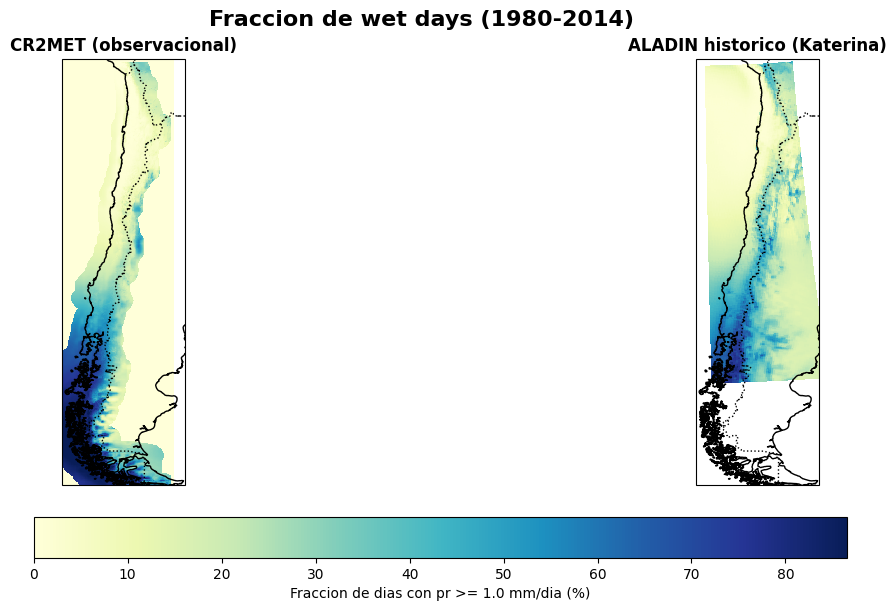

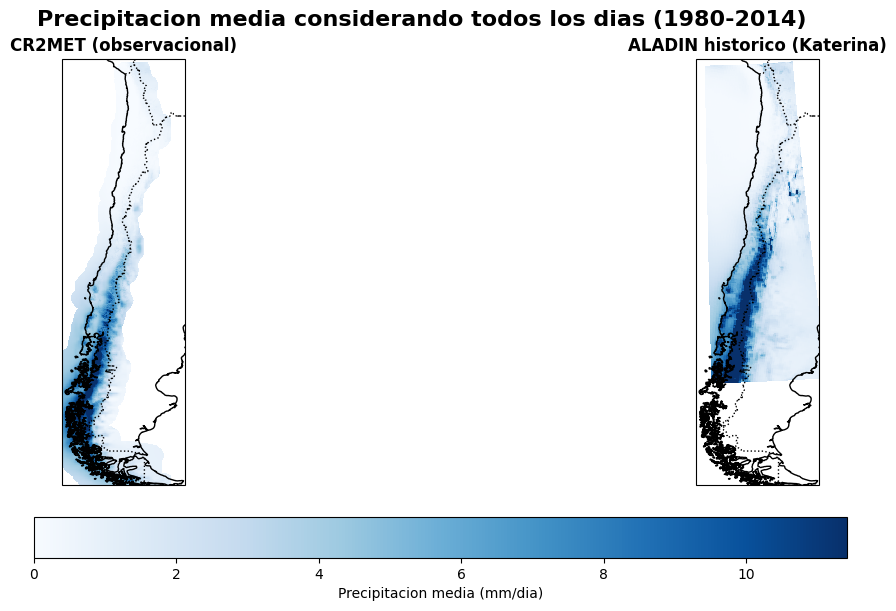

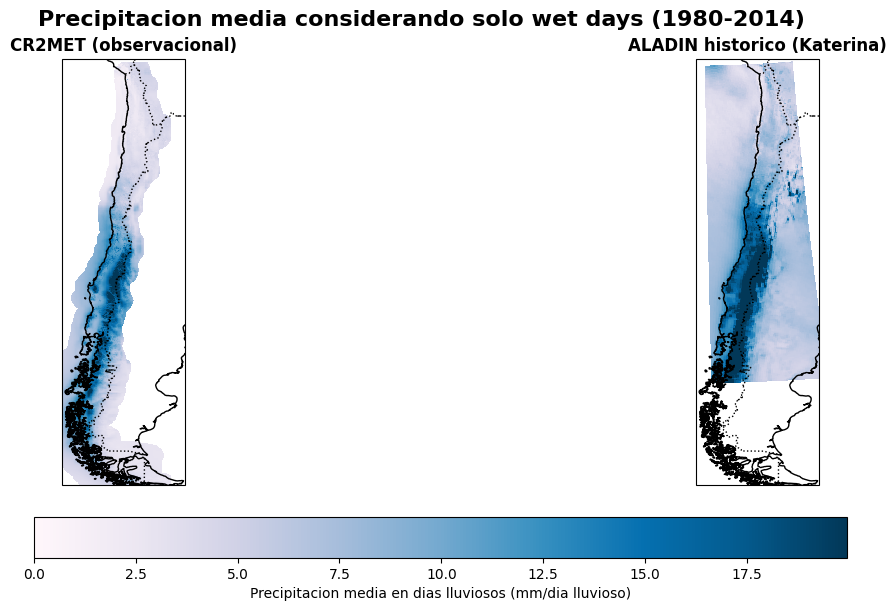

Las tres metricas usan el mismo periodo historico comun y la misma definicion de wet day.


In [3]:
# =====================================================================
# MAPAS COMPARATIVOS
# =====================================================================
print('3/3: Graficando mapas comparativos...')

wet_vmax = float(np.nanpercentile(np.concatenate([wet_frac_cr2met.values.ravel(), wet_frac_aladin.values.ravel()]), 98))
wet_vmax = max(wet_vmax, 10.0)
plot_two_panel_maps(
    wet_frac_cr2met,
    wet_frac_aladin,
    title='Fraccion de wet days (1980-2014)',
    cbar_label='Fraccion de dias con pr >= 1.0 mm/dia (%)',
    cmap='YlGnBu',
    vmin=0.0,
    vmax=wet_vmax,
)

mean_all_vmax = float(np.nanpercentile(np.concatenate([mean_all_cr2met.values.ravel(), mean_all_aladin.values.ravel()]), 98))
mean_all_vmax = max(mean_all_vmax, 1.0)
plot_two_panel_maps(
    mean_all_cr2met,
    mean_all_aladin,
    title='Precipitacion media considerando todos los dias (1980-2014)',
    cbar_label='Precipitacion media (mm/dia)',
    cmap='Blues',
    vmin=0.0,
    vmax=mean_all_vmax,
)

mean_wet_vmax = float(np.nanpercentile(np.concatenate([mean_wet_cr2met.values.ravel(), mean_wet_aladin.values.ravel()]), 98))
mean_wet_vmax = max(mean_wet_vmax, 1.0)
plot_two_panel_maps(
    mean_wet_cr2met,
    mean_wet_aladin,
    title='Precipitacion media considerando solo wet days (1980-2014)',
    cbar_label='Precipitacion media en dias lluviosos (mm/dia lluvioso)',
    cmap='PuBu',
    vmin=0.0,
    vmax=mean_wet_vmax,
)

print('Las tres metricas usan el mismo periodo historico comun y la misma definicion de wet day.')
